Preparing the dataset

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

%matplotlib inline

In [9]:
df = pd.read_csv("../data/car_fuel_efficiency_2026.csv")
columns = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df[columns]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


Exploratory Data Analysis

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

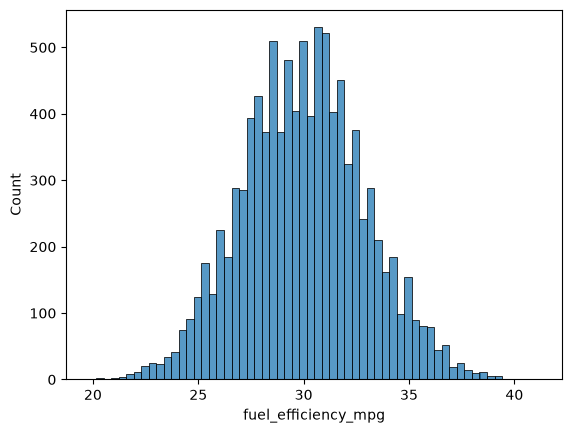

In [12]:
sns.histplot(df.fuel_efficiency_mpg)

Question 1: There's one column with missing values. What is it?

In [15]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Question 2: What's median (50% percentile) for variable 'horsepower'?

In [18]:
df['horsepower'].describe()

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

Prepare and split the dataset

In [23]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']


In [ ]:
Question 3

In [43]:
def prepare_X_with_zeros(df):
    df_res = df.copy()
    df_res['horsepower'] = df_res["horsepower"].fillna(0)
    X = df_res.values
    return X

def prepare_X_with_mean(df, mean_val):
    df_res = df.copy()
    df_res['horsepower'] = df_res['horsepower'].fillna(mean_val)
    X = df_res.values
    return X

def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [44]:
#X with 0
X_train = prepare_X_with_zeros(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X_with_zeros(df_val)
y_pred = w0 + X_val.dot(w)
print(f"RMSE for train data with 0: {rmse(y_val, y_pred).round(3)}")

RMSE for train data with 0: 2.205


In [46]:
#X with mean
mean_horsepower = df_train['horsepower'].mean()

X_train = prepare_X_with_mean(df_train, mean_horsepower)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X_with_mean(df_val, mean_horsepower)
y_pred = w0 + X_val.dot(w)
print(f"RMSE for train data with mean: {rmse(y_val, y_pred).round(3)}")

RMSE for train data with mean: 2.202


Question 4

In [47]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

for r in [0.0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X_with_zeros(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X_with_zeros(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred).round(3)

    print(f"r: {r}, RMSE: {score}")

r: 0.0, RMSE: 2.205
r: 0.01, RMSE: 2.206
r: 0.1, RMSE: 2.224
r: 1, RMSE: 2.349
r: 5, RMSE: 2.409
r: 10, RMSE: 2.419
r: 100, RMSE: 2.429


Question 5

In [49]:
scores = []
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    X_train = prepare_X_with_zeros(df_train)
    w0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X_with_zeros(df_val)
    y_pred = w0 + X_val.dot(w)
    scores.append(rmse(y_val, y_pred))

print(f"Standard deviation of all scores: {np.std(scores).round(3)}")

    

Standard deviation of all scores: 0.029


Question 6

In [52]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

X_train = prepare_X_with_zeros(df_train)
X_val = prepare_X_with_zeros(df_val)
X_full_train = np.concat([X_train, X_val])
y_full_train = np.concatenate([y_train, y_val])
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
X_test = prepare_X_with_zeros(df_test)
y_pred = w0 + X_test.dot(w)
rmse(y_test, y_pred).round(3)

np.float64(2.236)